In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Cấu hình thiết bị chạy (CPU hoặc GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

def train_model_generic(model, train_loader, test_loader, optimizer, criterion, num_epochs=5):
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(model, test_loader)
        loss_history.append(train_loss)
        acc_history.append(train_acc)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)
    return loss_history, acc_history, test_loss_history, test_acc_history

class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

criterion = nn.CrossEntropyLoss()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 131MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 54.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 29.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.61MB/s]


In [ ]:
#Cau 1

Epoch 1/10 | Train Loss: 0.1789 - Train Acc: 94.57% | Test Loss: 0.0693 - Test Acc: 97.72%
Epoch 2/10 | Train Loss: 0.0630 - Train Acc: 98.06% | Test Loss: 0.0533 - Test Acc: 98.20%
Epoch 3/10 | Train Loss: 0.0469 - Train Acc: 98.51% | Test Loss: 0.0546 - Test Acc: 98.24%
Epoch 4/10 | Train Loss: 0.0380 - Train Acc: 98.81% | Test Loss: 0.0383 - Test Acc: 98.75%
Epoch 5/10 | Train Loss: 0.0328 - Train Acc: 98.98% | Test Loss: 0.0308 - Test Acc: 98.99%
Epoch 6/10 | Train Loss: 0.0277 - Train Acc: 99.13% | Test Loss: 0.0314 - Test Acc: 98.88%
Epoch 7/10 | Train Loss: 0.0245 - Train Acc: 99.21% | Test Loss: 0.0313 - Test Acc: 99.02%
Epoch 8/10 | Train Loss: 0.0223 - Train Acc: 99.32% | Test Loss: 0.0329 - Test Acc: 99.03%
Epoch 9/10 | Train Loss: 0.0189 - Train Acc: 99.38% | Test Loss: 0.0315 - Test Acc: 99.00%
Epoch 10/10 | Train Loss: 0.0171 - Train Acc: 99.46% | Test Loss: 0.0331 - Test Acc: 99.00%


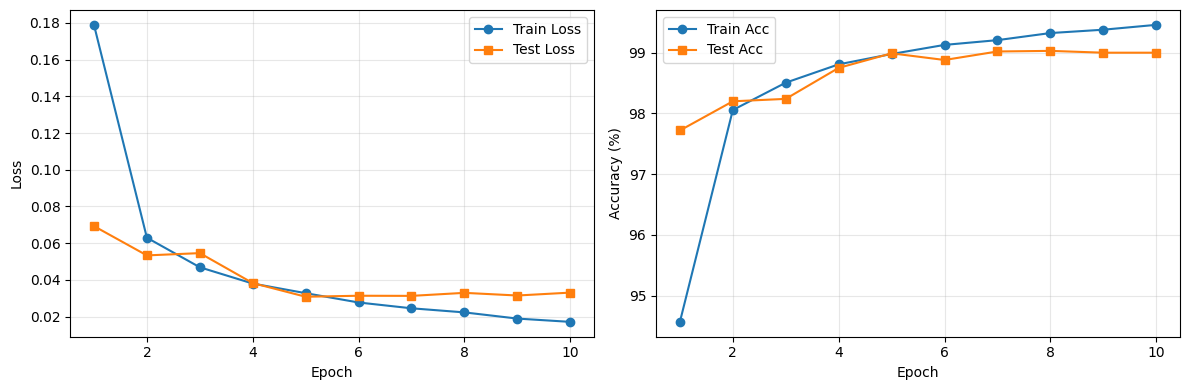

In [7]:
num_epochs = 10
model_c1 = MNIST_CNN().to(device)
optimizer_c1 = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)

loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model_c1.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_c1.zero_grad()
        outputs = model_c1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c1.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_c1, test_loader)

    loss_history.append(train_loss)
    acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | '
          f'Test Loss: {test_loss:.4f} - Test Acc: {test_acc*100:.2f}%')

epochs_range = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, loss_history, 'o-', label='Train Loss')
axes[0].plot(epochs_range, test_loss_history, 's-', label='Test Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, [a*100 for a in acc_history], 'o-', label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in test_acc_history], 's-', label='Test Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#Cau 2

In [ ]:
class Deep_MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model_c2 = Deep_MNIST_CNN().to(device)
print(model_c2)
print(f'Tổng số lượng tham số cấu hình mạng sâu: {sum(p.numel() for p in model_c2.parameters() if p.requires_grad):,}')

optimizer_c2 = optim.SGD(model_c2.parameters(), lr=0.01, momentum=0.9)
for epoch in range(3):
    model_c2.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_c2.zero_grad()
        loss = criterion(model_c2(images), labels)
        loss.backward()
        optimizer_c2.step()
    _, t_acc = evaluate(model_c2, test_loader)
    print(f"Epoch {epoch+1} - Test Accuracy mạng sâu: {t_acc*100:.2f}%")

In [ ]:
#Cau 3

In [10]:
lrs = [0.001, 0.01, 0.1]
lr_curves = {}

for lr in lrs:
    model_lr = MNIST_CNN().to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr, momentum=0.9)
    loss_epoch_tracker = []

    print(f"Bắt đầu chạy huấn luyện thử nghiệm với Learning Rate = {lr}...")
    for epoch in range(5):
        model_lr.train()
        running_loss = 0.0
        total_samples = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer_lr.zero_grad()
            outputs = model_lr(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_lr.step()
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
        loss_epoch_tracker.append(running_loss / total_samples)
    lr_curves[lr] = loss_epoch_tracker

plt.figure(figsize=(8, 5))
for lr in lrs:
    plt.plot(range(1, 6), lr_curves[lr], 'o-', label=f'lr = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Ảnh hưởng của Learning Rate đến Loss qua các Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Bắt đầu chạy huấn luyện thử nghiệm với Learning Rate = 0.001...


KeyboardInterrupt: 

In [ ]:
#Cau 4

In [11]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    # Lan truyền xuôi qua từng khối cấu trúc để hứng Feature Map
    fmap_conv1 = torch.relu(model.conv1(img))
    fmap_pool1 = model.pool(fmap_conv1)
    fmap_conv2 = torch.relu(model.conv2(fmap_pool1))

# Trực quan hóa bản đồ đặc trưng
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
# Hiển thị đặc trưng thu được từ tầng Conv1
for i in range(4):
    axes[0, i].imshow(fmap_conv1[0, i].cpu(), cmap='viridis')
    axes[0, i].set_title(f'Conv1 - Map #{i}')
    axes[0, i].axis('off')
# Hiển thị đặc trưng thu được từ tầng Conv2
for i in range(4):
    axes[1, i].imshow(fmap_conv2[0, i].cpu(), cmap='viridis')
    axes[1, i].set_title(f'Conv2 - Map #{i}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

In [ ]:
#Cau 5

In [5]:
train_transform_augmented = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_augmented)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

class Dropout_MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc1(x)
        return x

model_c5 = Dropout_MNIST_CNN().to(device)
optimizer_c5 = optim.SGD(model_c5.parameters(), lr=0.01, momentum=0.9)

print("Bắt đầu train mạng có Dropout và Data Augmentation (10 epochs)...")
for epoch in range(10):
    model_c5.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_c5.zero_grad()
        outputs = model_c5(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c5.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_c5, test_loader)
    print(f'Epoch {epoch+1}/10 | Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%')

NameError: name 'transforms' is not defined